## Del Ke al WACC

El CAPM nos da el **costo del capital accionario (Ke)** — lo que exigen los accionistas.
Pero las empresas también se financian con deuda. El **WACC** promedia ambos costos 
según la estructura de capital de la empresa:

$$WACC = K_e \times \frac{E}{V} + K_d \times (1-t) \times \frac{D}{V}$$

El costo de la deuda (Kd) se multiplica por (1−t) porque los intereses son deducibles 
de impuestos

**Hallazgo para Tesla:** el WACC (20.50%) es prácticamente igual al Ke (20.69%) porque 
Tesla se financia un 99% con capital accionario. La deuda representa apenas el 1% de su 
estructura de capital, por lo que el escudo fiscal tiene un impacto mínimo.

In [4]:
import yfinance as yf

tsla = yf.Ticker("TSLA")
print(tsla.info.keys())

dict_keys(['address1', 'city', 'state', 'zip', 'country', 'phone', 'website', 'industry', 'industryKey', 'industryDisp', 'sector', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'fullTimeEmployees', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'shareHolderRightsRisk', 'overallRisk', 'governanceEpochDate', 'compensationAsOfEpochDate', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'payoutRatio', 'beta', 'trailingPE', 'forwardPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'marketCap', 'nonDilutedMarketCap', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', 'trailingAnnualDividendRate', 'trailingAnnualDividendYield', 'currency', 'tradeable', 'enter

In [5]:
print("Deuda total:     ", tsla.info.get('totalDebt'))
print("Market Cap:      ", tsla.info.get('marketCap'))
print("Deuda/Capital:   ", tsla.info.get('debtToEquity'))
print()

# Estados financieros
print(tsla.financials.loc[['Tax Provision', 'Pretax Income', 'Interest Expense']].iloc[:, 0])

Deuda total:      15889999872
Market Cap:       1538419589120
Deuda/Capital:    18.738

Tax Provision       1.423000e+09
Pretax Income       5.278000e+09
Interest Expense    3.380000e+08
Name: 2025-12-31 00:00:00, dtype: float64


In [6]:
# Datos de Tesla
deuda = 15889999872
market_cap = 1538419589120
interest_expense = 338000000
tax_provision = 1423000000
pretax_income = 5278000000

# Cálculos
kd = (interest_expense / deuda) * 100
t = tax_provision / pretax_income
V = deuda + market_cap
E_V = market_cap / V
D_V = deuda / V

print(f"Costo de la deuda (Kd):          {kd:.2f}%")
print(f"Tasa impositiva efectiva (t):     {t*100:.2f}%")
print(f"Proporción capital (E/V):         {E_V*100:.2f}%")
print(f"Proporción deuda (D/V):           {D_V*100:.2f}%")

Costo de la deuda (Kd):          2.13%
Tasa impositiva efectiva (t):     26.96%
Proporción capital (E/V):         98.98%
Proporción deuda (D/V):           1.02%


In [7]:
WACC = (E_V * costo_capital) + (D_V * kd * (1 - t))

print(f"Ke (costo del capital):           {costo_capital:.2f}%")
print(f"Kd después de impuestos:          {kd * (1-t):.2f}%")
print(f"─────────────────────────────────────────")
print(f"WACC de Tesla:                    {WACC:.2f}%")

Ke (costo del capital):           20.69%
Kd después de impuestos:          1.55%
─────────────────────────────────────────
WACC de Tesla:                    20.50%


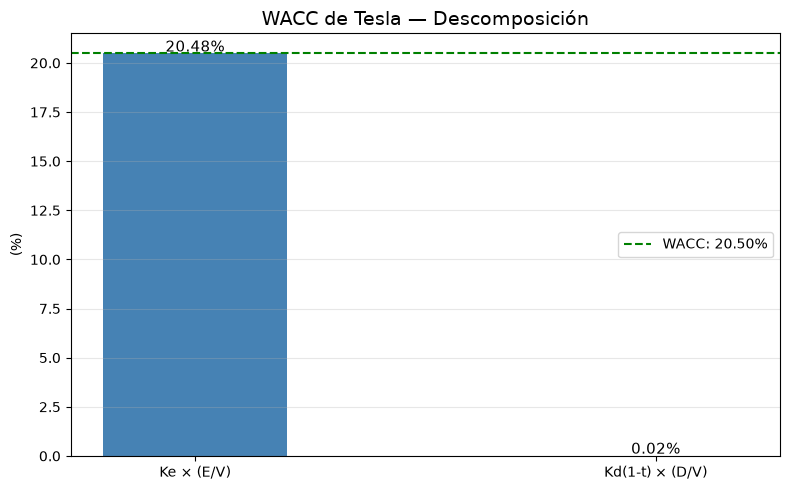

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

componentes = ['Ke × (E/V)', 'Kd(1-t) × (D/V)']
valores = [E_V * costo_capital, D_V * kd * (1 - t)]

bars = ax.bar(componentes, valores, color=['steelblue', 'coral'], width=0.4)

ax.axhline(WACC, color='green', linestyle='--', linewidth=1.5,
           label=f'WACC: {WACC:.2f}%')

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', fontsize=11)

ax.set_title('WACC de Tesla — Descomposición', fontsize=14)
ax.set_ylabel('(%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()